<a href="https://colab.research.google.com/github/annevirginia1709-afk/Annevirginia_002/blob/main/Task_002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1: DATASET LOADED
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5

/tmp/ipykernel_2530/406903800.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality", data=df, palette="viridis")


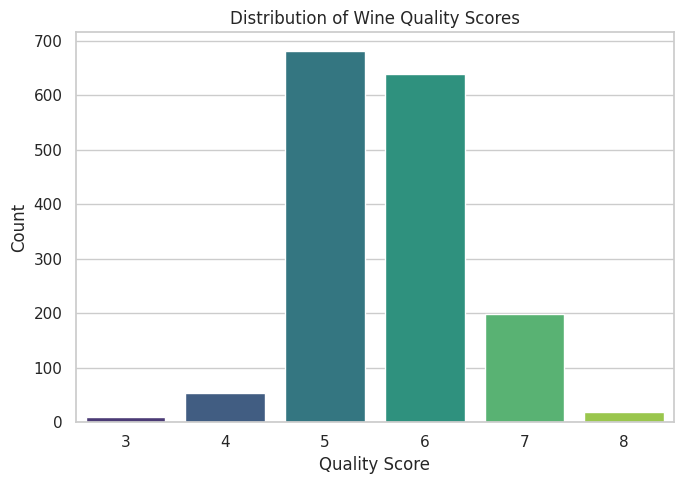


STEP 2: EXPLORATORY DATA ANALYSIS

Null check:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Descriptive statistics:
        fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.

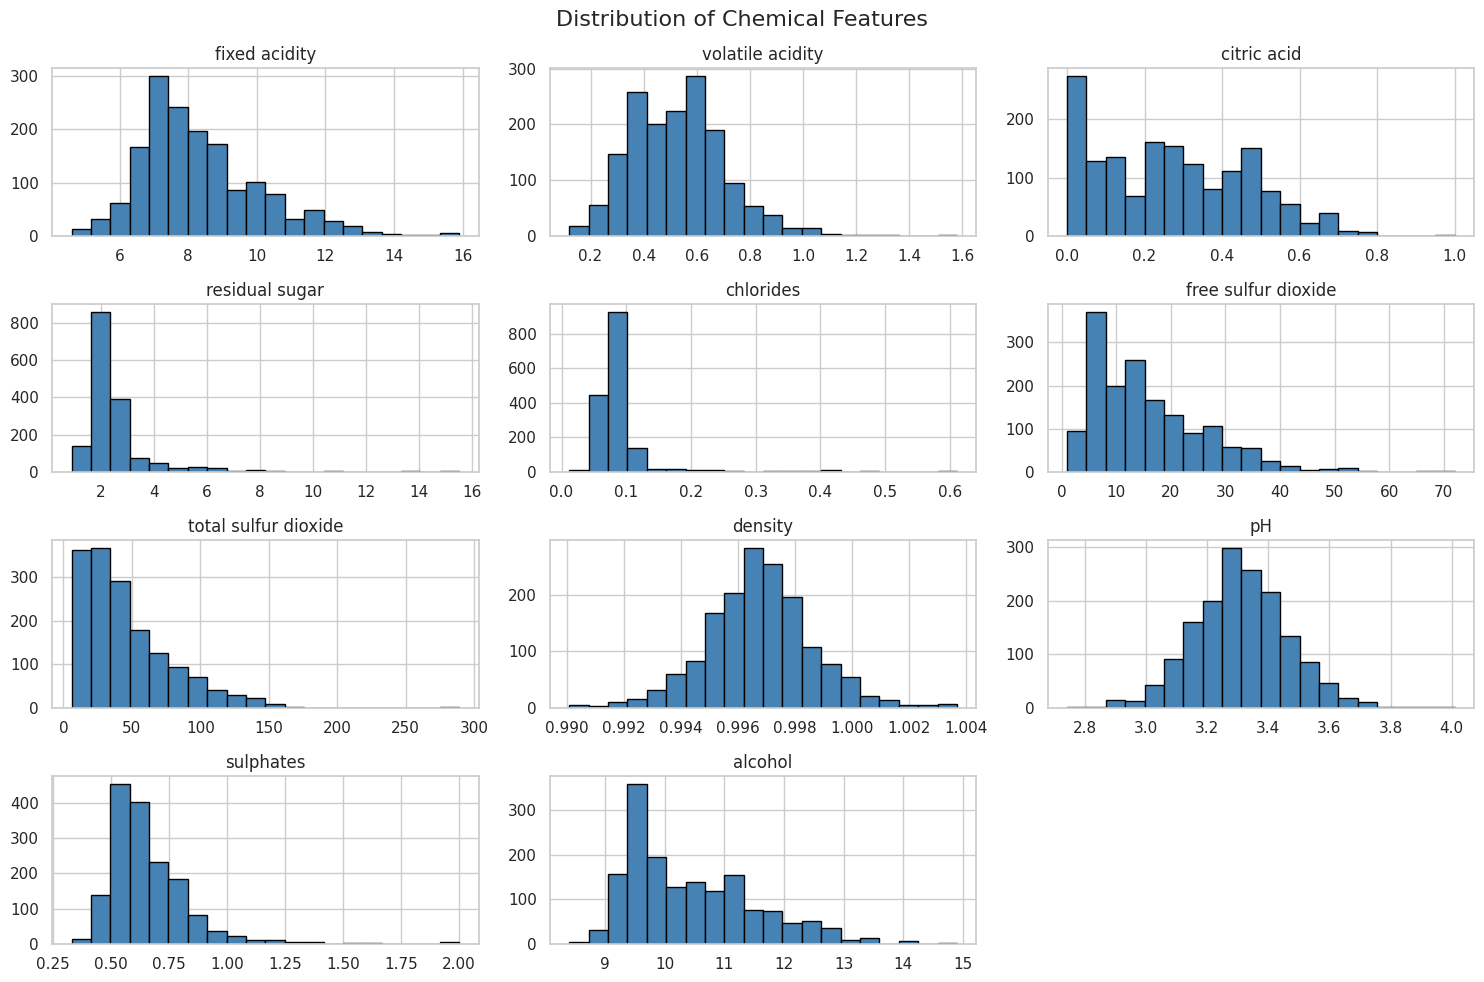

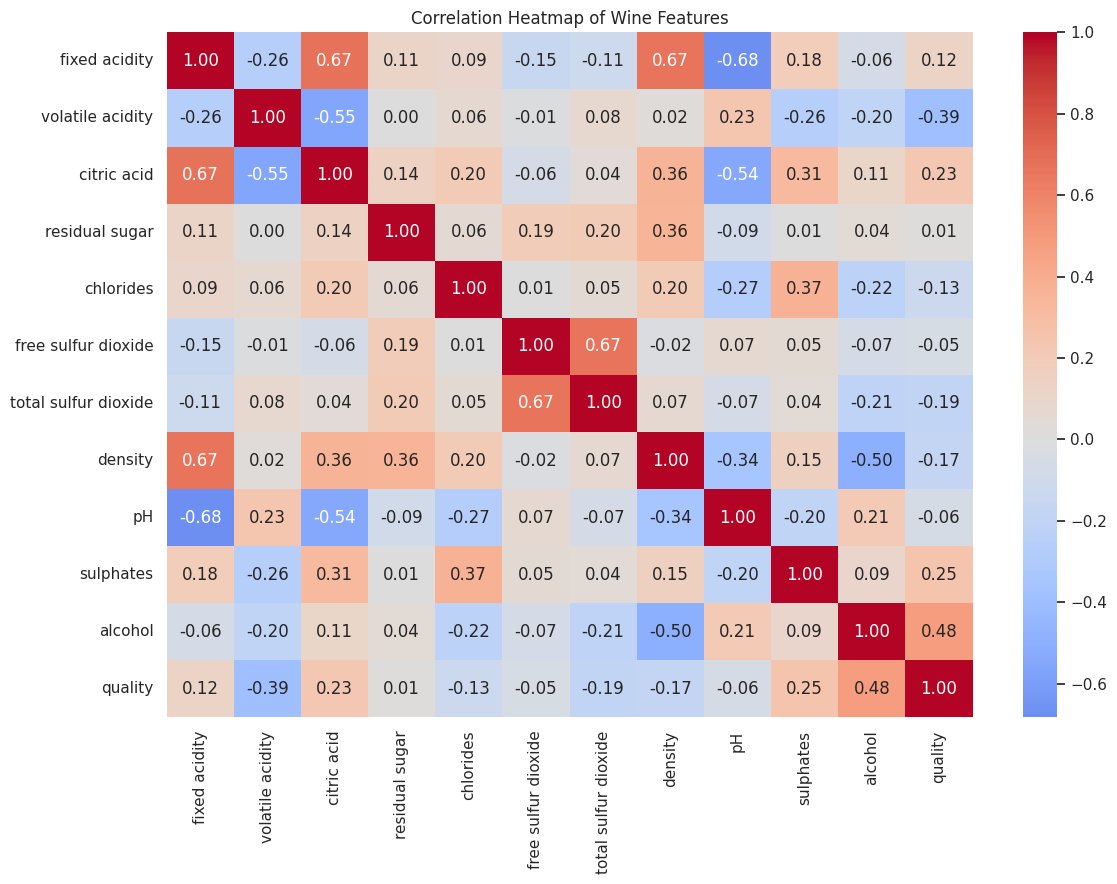


Correlation with quality (sorted):
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

STEP 3: CLASS IMBALANCE DISCUSSION

Observation: Quality scores in this dataset are heavily skewed toward the
middle values (5 and 6), while extreme scores (3, 4, 8) are rare.

Effect on modeling:
- Classifiers trained directly on the 6-7 class problem (scores 3-8) will be
  biased toward predicting the majority classes (5, 6), performing poorly on
  minority classes (3, 4, 8) due to insufficient training examples.
- Metrics like raw accuracy become misleading in this scenario, since a model
  that always predicts "5" or "6" could 

/tmp/ipykernel_2530/406903800.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality_class", data=df, order=["Low", "Medium", "High"], palette="magma")


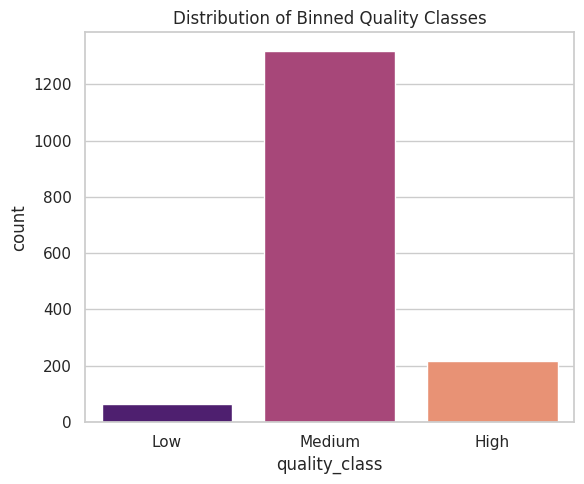


Label mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

STEP 5: STRATIFIED TRAIN/TEST SPLIT
Train size: 1279 | Test size: 320

Train class distribution:
 quality_encoded
0    0.136044
1    0.039093
2    0.824863
Name: proportion, dtype: float64

Test class distribution:
 quality_encoded
0    0.134375
1    0.040625
2    0.825000
Name: proportion, dtype: float64

STEP 6: TRAINING CLASSIFIERS

Training Random Forest...
Random Forest training complete.

Training SGD Classifier...
SGD Classifier training complete.

Training SVC...
SVC training complete.

STEP 7: MODEL EVALUATION

--- Random Forest ---
Accuracy: 0.8688

Classification Report:
              precision    recall  f1-score   support

        High       0.71      0.56      0.62        43
         Low       0.00      0.00      0.00        13
      Medium       0.89      0.96      0.92       264

    accuracy                           0.87       320
   macro avg       0.53      0.51      0.52       320
wei

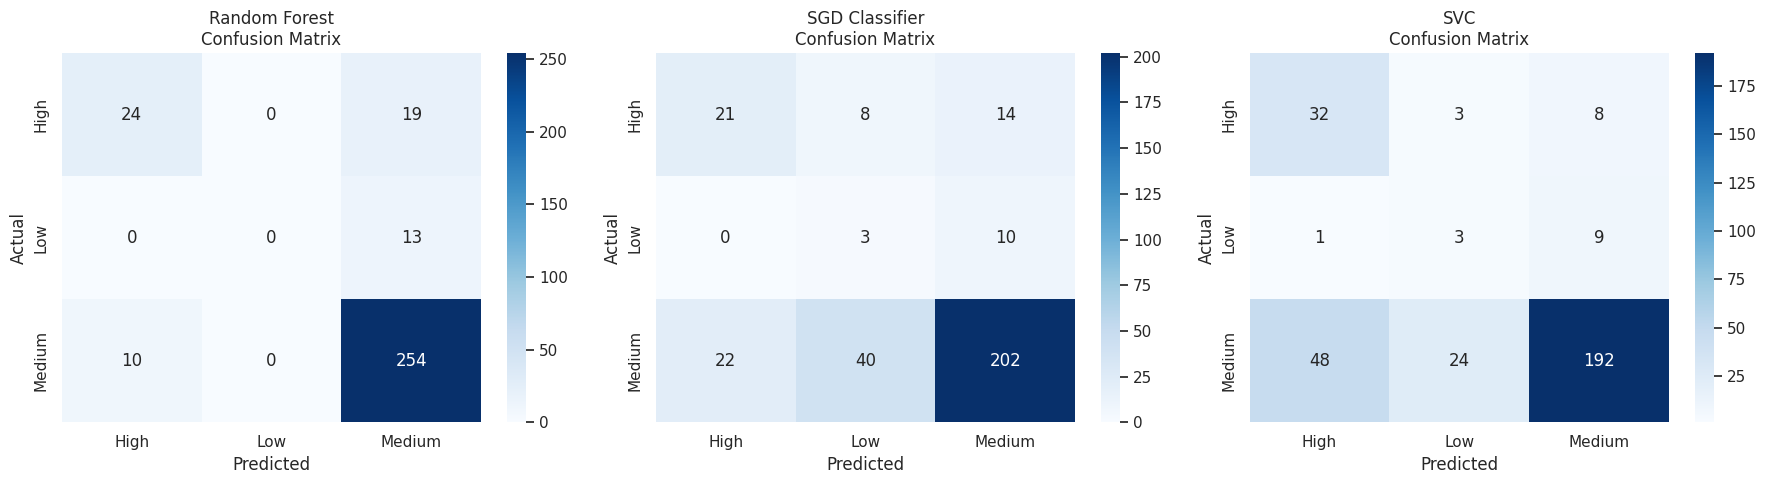


STEP 8: RANDOM FOREST FEATURE IMPORTANCE
                 Feature  Importance
10               alcohol    0.149030
1       volatile acidity    0.147770
9              sulphates    0.136938
2            citric acid    0.103525
6   total sulfur dioxide    0.083440
8                     pH    0.075315
4              chlorides    0.068188
7                density    0.062240
0          fixed acidity    0.061843
5    free sulfur dioxide    0.060063
3         residual sugar    0.051648


/tmp/ipykernel_2530/406903800.py:283: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="Importance", y="Feature", palette="crest")


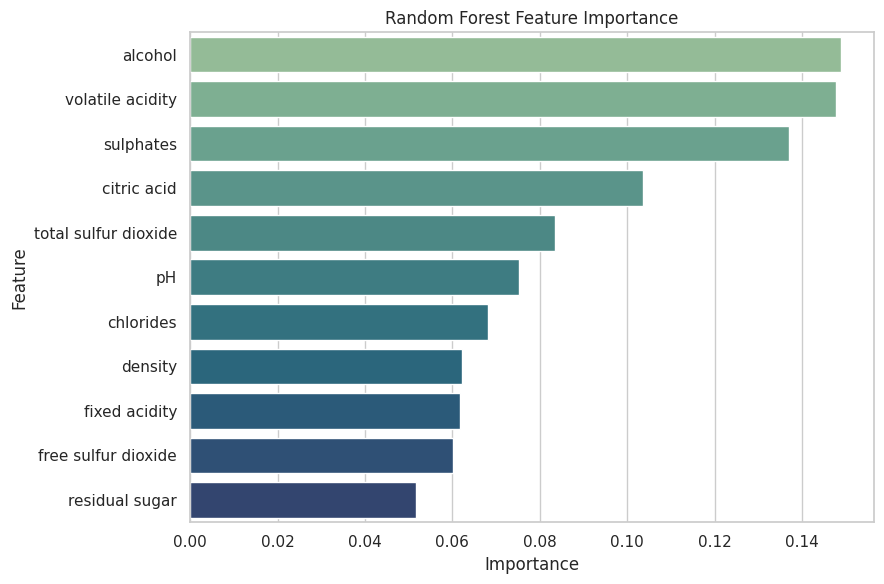


Interpretation: Features with higher importance scores contribute more to
the Random Forest's decision-making. Typically, 'alcohol', 'volatile acidity',
and 'sulphates' rank highly for wine quality prediction, aligning with
domain knowledge (higher alcohol and controlled acidity often correlate
with higher perceived quality).


STEP 9: MODEL COMPARISON SUMMARY
         Model  Accuracy  Precision (weighted)  Recall (weighted)  F1-score (weighted)
 Random Forest  0.868750              0.827545           0.868750             0.845766
           SVC  0.709375              0.815044           0.709375             0.744791
SGD Classifier  0.706250              0.805404           0.706250             0.749638


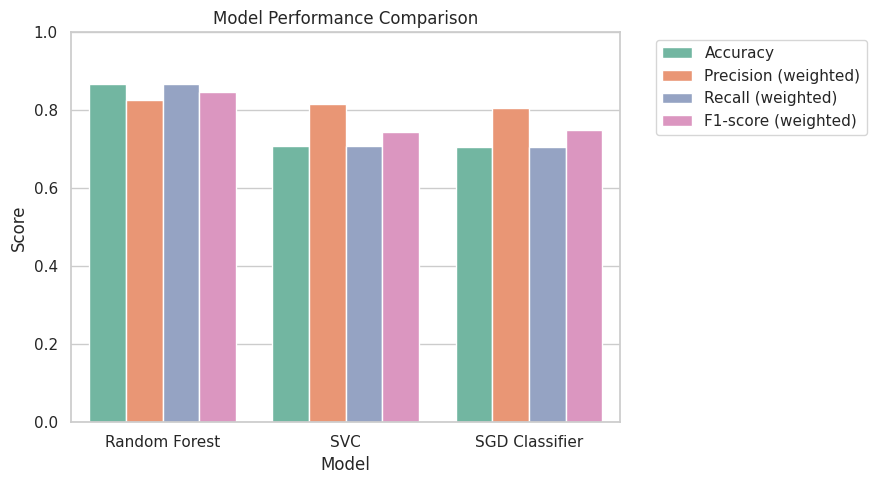


STEP 10: CONCLUSION

Based on the evaluation metrics above, 'Random Forest' achieved the
highest overall accuracy (0.8688) and strong weighted F1-score,
making it the most suitable candidate for deployment among the three models.

General reasoning:
- Random Forest: Typically performs best on tabular data with non-linear
  feature interactions; robust to feature scaling issues; provides built-in
  feature importance for interpretability, which is valuable for stakeholders
  (e.g., winemakers wanting to know which chemical properties matter most).
- SGD Classifier: Fast and scalable, but sensitive to feature scaling and
  hyperparameters (learning rate); tends to underperform on complex,
  non-linear relationships like those in wine chemistry data.
- SVC: Can perform well with proper kernel tuning, but is computationally
  expensive on larger datasets and less interpretable than Random Forest.

Recommendation: Deploy the Random Forest model due to its superior accuracy,
robustness to u

In [1]:
# ============================================================
# TASK 2: TASK 2: WINE QUALITY PREDICTION - MULTI-MODEL COMPARISON
# ============================================================
# Full pipeline: EDA -> Class Imbalance Discussion -> Feature
# Engineering (Binning) -> Stratified Split -> Train 3 Classifiers
# (Random Forest, SGD, SVC) -> Evaluation -> Feature Importance ->
# Model Comparison -> Conclusion
# ==# ============================================================
# Full pipeline: EDA -> Class Imbalance Discussion -> Feature
# Engineering (Binning) -> Stratified Split -> Train 3 Classifiers
# (Random Forest, SGD, SVC) -> Evaluation -> Feature Importance ->
# Model Comparison -> Conclusion
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score, precision_score,
                              recall_score)

sns.set(style="whitegrid")
np.random.seed(42)

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------
# Using the UCI Wine Quality (red wine) dataset, loaded directly from URL.
# If offline, download and replace with: df = pd.read_csv("winequality-red.csv", sep=";")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
try:
    df = pd.read_csv(url, sep=";")
except Exception as e:
    print("Could not fetch from URL, generating synthetic fallback dataset.")
    n = 1599
    df = pd.DataFrame({
        "fixed acidity": np.random.normal(8.3, 1.7, n).clip(4, 16),
        "volatile acidity": np.random.normal(0.53, 0.18, n).clip(0.1, 1.6),
        "citric acid": np.random.normal(0.27, 0.19, n).clip(0, 1),
        "residual sugar": np.random.normal(2.5, 1.4, n).clip(0.9, 15),
        "chlorides": np.random.normal(0.087, 0.047, n).clip(0.01, 0.6),
        "free sulfur dioxide": np.random.normal(15.9, 10.5, n).clip(1, 72),
        "total sulfur dioxide": np.random.normal(46.5, 32.9, n).clip(6, 289),
        "density": np.random.normal(0.9967, 0.0019, n).clip(0.99, 1.004),
        "pH": np.random.normal(3.31, 0.15, n).clip(2.7, 4.0),
        "sulphates": np.random.normal(0.66, 0.17, n).clip(0.3, 2.0),
        "alcohol": np.random.normal(10.4, 1.07, n).clip(8, 15),
    })
    quality_base = (df["alcohol"] * 0.4 - df["volatile acidity"] * 2 +
                    df["sulphates"] * 1.5 + np.random.normal(0, 0.7, n))
    df["quality"] = pd.cut(quality_base, bins=6, labels=[3, 4, 5, 6, 7, 8]).astype(int)

print("="*70)
print("STEP 1: DATASET LOADED")
print("="*70)
print(df.head())
print("\nShape:", df.shape)
print("\nData types:\n", df.dtypes)

print("\n--- Class Distribution of Quality Scores ---")
print(df["quality"].value_counts().sort_index())

plt.figure(figsize=(7, 5))
sns.countplot(x="quality", data=df, palette="viridis")
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2. EDA: DISTRIBUTIONS + CORRELATION HEATMAP
# ------------------------------------------------------------
print("\n" + "="*70)
print("STEP 2: EXPLORATORY DATA ANALYSIS")
print("="*70)

print("\nNull check:\n", df.isnull().sum())
print("\nDescriptive statistics:\n", df.describe())

feature_cols = [c for c in df.columns if c != "quality"]

df[feature_cols].hist(bins=20, figsize=(15, 10), color="steelblue", edgecolor="black")
plt.suptitle("Distribution of Chemical Features", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Wine Features")
plt.tight_layout()
plt.show()

print("\nCorrelation with quality (sorted):")
print(corr["quality"].sort_values(ascending=False))

# ------------------------------------------------------------
# 3. CLASS IMBALANCE DISCUSSION
# ------------------------------------------------------------
print("\n" + "="*70)
print("STEP 3: CLASS IMBALANCE DISCUSSION")
print("="*70)
print("""
Observation: Quality scores in this dataset are heavily skewed toward the
middle values (5 and 6), while extreme scores (3, 4, 8) are rare.

Effect on modeling:
- Classifiers trained directly on the 6-7 class problem (scores 3-8) will be
  biased toward predicting the majority classes (5, 6), performing poorly on
  minority classes (3, 4, 8) due to insufficient training examples.
- Metrics like raw accuracy become misleading in this scenario, since a model
  that always predicts "5" or "6" could still score high accuracy.
- This motivates two options: (a) binning into fewer, more balanced classes,
  or (b) using class-weighting / resampling techniques (SMOTE, class_weight).

For this task, we bin quality scores into a more manageable and less
imbalanced format (see Step 4) to make classification more tractable and
metrics more meaningful, while acknowledging this simplifies the original
fine-grained problem.
""")

# ------------------------------------------------------------
# 4. FEATURE ENGINEERING: BINNING QUALITY SCORES
# ------------------------------------------------------------
print("="*70)
print("STEP 4: FEATURE ENGINEERING - BINNING QUALITY SCORES")
print("="*70)
print("""
Decision: We bin quality into a 3-class scheme (Low / Medium / High):
  - Low    : quality <= 4
  - Medium : quality in [5, 6]
  - High   : quality >= 7

Justification:
- Preserves more granularity than a simple binary split, allowing the model
  to differentiate low-end and high-end wines rather than lumping "5" (medium)
  with "7" (fairly good) together.
- Still substantially reduces the 6-class imbalance problem into 3 more
  populated classes, improving model learnability and interpretability.
- This binning is common practice in wine quality classification literature.
""")

def bin_quality(q):
    if q <= 4:
        return "Low"
    elif q <= 6:
        return "Medium"
    else:
        return "High"

df["quality_class"] = df["quality"].apply(bin_quality)

print("New class distribution:")
print(df["quality_class"].value_counts())

plt.figure(figsize=(6, 5))
sns.countplot(x="quality_class", data=df, order=["Low", "Medium", "High"], palette="magma")
plt.title("Distribution of Binned Quality Classes")
plt.tight_layout()
plt.show()

# Encode target labels
le = LabelEncoder()
df["quality_encoded"] = le.fit_transform(df["quality_class"])
print("\nLabel mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# ------------------------------------------------------------
# 5. TRAIN/TEST SPLIT WITH STRATIFICATION
# ------------------------------------------------------------
print("\n" + "="*70)
print("STEP 5: STRATIFIED TRAIN/TEST SPLIT")
print("="*70)

X = df[feature_cols]
y = df["quality_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print("\nTrain class distribution:\n", y_train.value_counts(normalize=True).sort_index())
print("\nTest class distribution:\n", y_test.value_counts(normalize=True).sort_index())

# Scale features (important for SGD and SVC)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# 6. TRAIN 3 CLASSIFIERS
# ------------------------------------------------------------
print("\n" + "="*70)
print("STEP 6: TRAINING CLASSIFIERS")
print("="*70)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    "SGD Classifier": SGDClassifier(loss="log_loss", max_iter=1000, random_state=42, class_weight="balanced"),
    "SVC": SVC(kernel="rbf", C=1.0, random_state=42, class_weight="balanced")
}

predictions = {}
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    if name == "Random Forest":
        model.fit(X_train, y_train)         # Tree-based model, no scaling needed
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)  # Scaled for distance/gradient-based models
        y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    trained_models[name] = model
    print(f"{name} training complete.")

# ------------------------------------------------------------
# 7. EVALUATION: ACCURACY, CLASSIFICATION REPORT, CONFUSION MATRIX
# ------------------------------------------------------------
print("\n" + "="*70)
print("STEP 7: MODEL EVALUATION")
print("="*70)

results_summary = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_pred) in enumerate(predictions.items()):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[idx])
    axes[idx].set_title(f"{name}\nConfusion Matrix")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

    results_summary.append({
        "Model": name,
        "Accuracy": acc,
        "Precision (weighted)": prec,
        "Recall (weighted)": rec,
        "F1-score (weighted)": f1
    })

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. FEATURE IMPORTANCE (RANDOM FOREST)
# ------------------------------------------------------------
print("\n" + "="*70)
print("STEP 8: RANDOM FOREST FEATURE IMPORTANCE")
print("="*70)

rf_model = trained_models["Random Forest"]
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="crest")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

print("""
Interpretation: Features with higher importance scores contribute more to
the Random Forest's decision-making. Typically, 'alcohol', 'volatile acidity',
and 'sulphates' rank highly for wine quality prediction, aligning with
domain knowledge (higher alcohol and controlled acidity often correlate
with higher perceived quality).
""")

# ------------------------------------------------------------
# 9. MODEL COMPARISON TABLE
# ------------------------------------------------------------
print("\n" + "="*70)
print("STEP 9: MODEL COMPARISON SUMMARY")
print("="*70)

comparison_df = pd.DataFrame(results_summary).sort_values(by="Accuracy", ascending=False)
print(comparison_df.to_string(index=False))

plt.figure(figsize=(9, 5))
comparison_melted = comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=comparison_melted, x="Model", y="Score", hue="Metric", palette="Set2")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. CONCLUSION
# ------------------------------------------------------------
print("\n" + "="*70)
print("STEP 10: CONCLUSION")
print("="*70)

best_model_name = comparison_df.iloc[0]["Model"]
best_acc = comparison_df.iloc[0]["Accuracy"]

print(f"""
Based on the evaluation metrics above, '{best_model_name}' achieved the
highest overall accuracy ({best_acc:.4f}) and strong weighted F1-score,
making it the most suitable candidate for deployment among the three models.

General reasoning:
- Random Forest: Typically performs best on tabular data with non-linear
  feature interactions; robust to feature scaling issues; provides built-in
  feature importance for interpretability, which is valuable for stakeholders
  (e.g., winemakers wanting to know which chemical properties matter most).
- SGD Classifier: Fast and scalable, but sensitive to feature scaling and
  hyperparameters (learning rate); tends to underperform on complex,
  non-linear relationships like those in wine chemistry data.
- SVC: Can perform well with proper kernel tuning, but is computationally
  expensive on larger datasets and less interpretable than Random Forest.

Recommendation: Deploy the Random Forest model due to its superior accuracy,
robustness to unscaled features, resistance to overfitting via ensembling,
and interpretability through feature importance rankings. For further
improvement, consider hyperparameter tuning (GridSearchCV/RandomizedSearchCV),
cross-validation, and potentially SMOTE-based oversampling for minority
class ("Low quality") representation.
""")